In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [ ]:
import os

for root, dirs, files in os.walk("/kaggle/input/brain-tumor-mri-dataset"):
    for d in dirs:
        print(os.path.join(root, d))


/kaggle/input/brain-tumor-mri-dataset/Training
/kaggle/input/brain-tumor-mri-dataset/Testing
/kaggle/input/brain-tumor-mri-dataset/Training/pituitary
/kaggle/input/brain-tumor-mri-dataset/Training/notumor
/kaggle/input/brain-tumor-mri-dataset/Training/meningioma
/kaggle/input/brain-tumor-mri-dataset/Training/glioma
/kaggle/input/brain-tumor-mri-dataset/Testing/pituitary
/kaggle/input/brain-tumor-mri-dataset/Testing/notumor
/kaggle/input/brain-tumor-mri-dataset/Testing/meningioma
/kaggle/input/brain-tumor-mri-dataset/Testing/glioma


In [ ]:
import os

# Define the base directories
train_dir = "/kaggle/input/brain-tumor-mri-dataset/Training"
test_dir  = "/kaggle/input/brain-tumor-mri-dataset/Testing"

def count_images_in_subfolders(base_dir):
    print(f"\n📁 Image counts in: {base_dir}\n")
    total = 0
    for folder in sorted(os.listdir(base_dir)):
        folder_path = os.path.join(base_dir, folder)
        if os.path.isdir(folder_path):
            count = len([
                f for f in os.listdir(folder_path)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))
            ])
            print(f"{folder:20s} : {count} images")
            total += count
    print(f"➡️ Total images in {os.path.basename(base_dir)}: {total}\n")
    return total

# Count images in both folders
train_total = count_images_in_subfolders(train_dir)
test_total  = count_images_in_subfolders(test_dir)

print(f"✅ Grand Total (Training + Testing): {train_total + test_total} images")



📁 Image counts in: /kaggle/input/brain-tumor-mri-dataset/Training

glioma               : 1321 images
meningioma           : 1339 images
notumor              : 1595 images
pituitary            : 1457 images
➡️ Total images in Training: 5712


📁 Image counts in: /kaggle/input/brain-tumor-mri-dataset/Testing

glioma               : 300 images
meningioma           : 306 images
notumor              : 405 images
pituitary            : 300 images
➡️ Total images in Testing: 1311

✅ Grand Total (Training + Testing): 7023 images


In [ ]:
import os
import shutil

# Source directories
train_dir = "/kaggle/input/brain-tumor-mri-dataset/Training"
test_dir  = "/kaggle/input/brain-tumor-mri-dataset/Testing"

# Destination directory
merged_dir = "/kaggle/working/Brain_Tumor_Merged"

# Create destination folder if it doesn’t exist
os.makedirs(merged_dir, exist_ok=True)

# Merge images from both directories
for src_dir in [train_dir, test_dir]:
    for folder in os.listdir(src_dir):
        src_folder = os.path.join(src_dir, folder)
        if os.path.isdir(src_folder):
            dest_folder = os.path.join(merged_dir, folder)
            os.makedirs(dest_folder, exist_ok=True)
            for file in os.listdir(src_folder):
                if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    src_path = os.path.join(src_folder, file)
                    dest_path = os.path.join(dest_folder, file)

                    # Avoid overwriting files with same name
                    if os.path.exists(dest_path):
                        base, ext = os.path.splitext(file)
                        i = 1
                        while os.path.exists(dest_path):
                            dest_path = os.path.join(dest_folder, f"{base}_{i}{ext}")
                            i += 1
                    shutil.copy2(src_path, dest_path)

print("✅ Merge completed! All images copied to:", merged_dir)


print("\n📊 Checking merged folder image counts:\n")
total = 0
for folder in os.listdir(merged_dir):
    folder_path = os.path.join(merged_dir, folder)
    if os.path.isdir(folder_path):
        count = len([f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        print(f"{folder:20s} : {count} images")
        total += count
print(f"\n➡️ Total images in merged folder: {total}")


✅ Merge completed! All images copied to: /kaggle/working/Brain_Tumor_Merged

📊 Checking merged folder image counts:

notumor              : 2000 images
pituitary            : 1757 images
meningioma           : 1645 images
glioma               : 1621 images

➡️ Total images in merged folder: 7023



Processing class: glioma (1621 images)


glioma Progress: 100%|█████████████████████████████████████████| 1621/1621 [00:08<00:00, 186.37it/s]



Processing class: meningioma (1645 images)


meningioma Progress: 100%|█████████████████████████████████████| 1645/1645 [00:08<00:00, 205.12it/s]



Processing class: notumor (2000 images)


notumor Progress: 100%|████████████████████████████████████████| 2000/2000 [00:08<00:00, 224.53it/s]



Processing class: pituitary (1757 images)


pituitary Progress: 100%|██████████████████████████████████████| 1757/1757 [00:08<00:00, 200.69it/s]


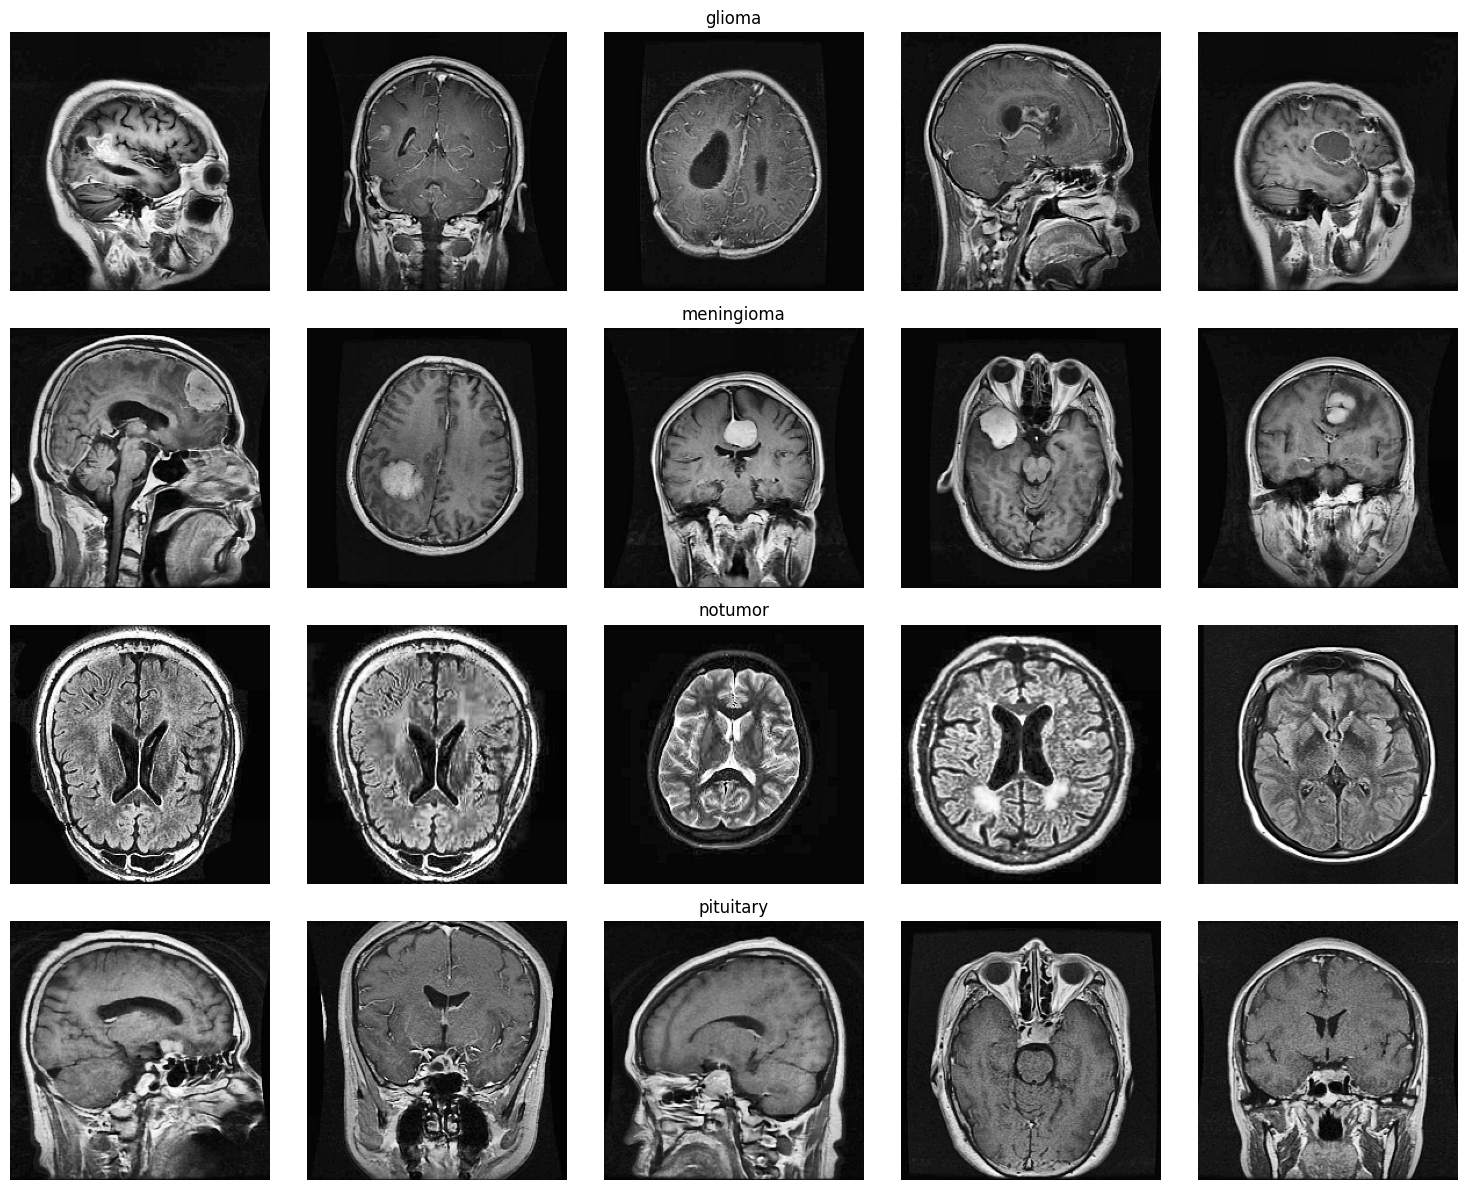


✅ Preprocessed images saved in: /kaggle/working/preprocessed_dataset


In [ ]:
import os
import cv2
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import random
from tqdm import tqdm

# Paths
input_dir = "/kaggle/working/Brain_Tumor_Merged"
output_dir = "/kaggle/working/preprocessed_dataset"
os.makedirs(output_dir, exist_ok=True)

img_size = (224, 224)
num_samples = 5
device = "cuda" if torch.cuda.is_available() else "cpu"

# Gaussian filter (GPU)
def gaussian_filter_gpu(img_tensor, kernel_size=5, sigma=1.0):
    C,H,W = img_tensor.shape
    x = torch.arange(kernel_size, dtype=torch.float32, device=img_tensor.device) - kernel_size//2
    gauss = torch.exp(-(x**2)/(2*sigma**2))
    gauss = gauss / gauss.sum()
    gauss_2d = gauss[:, None] @ gauss[None, :]
    gauss_2d = gauss_2d.expand(C,1,kernel_size,kernel_size)
    img_tensor = img_tensor.unsqueeze(0)
    img_filtered = F.conv2d(img_tensor, gauss_2d, padding=kernel_size//2, groups=C)
    return img_filtered[0]

# Classes
classes = sorted([d for d in os.listdir(input_dir) if os.path.isdir(os.path.join(input_dir, d))])

fig, axes = plt.subplots(len(classes), num_samples, figsize=(15,3*len(classes)))

for i, cls in enumerate(classes):
    cls_path = os.path.join(input_dir, cls)
    save_cls_path = os.path.join(output_dir, cls)
    os.makedirs(save_cls_path, exist_ok=True)

    files = [f for f in os.listdir(cls_path) if f.lower().endswith((".jpg",".png",".jpeg"))]
    sample_files = random.sample(files, min(num_samples,len(files)))

    print(f"\nProcessing class: {cls} ({len(files)} images)")
    for file in tqdm(files, desc=f"{cls} Progress", ncols=100):
        img_path = os.path.join(cls_path, file)
        img = cv2.imread(img_path)
        if img is None:
            continue

        # 1️⃣ Resize
        img_resized = cv2.resize(img, img_size)

        # 2️⃣ CLAHE on L channel
        lab = cv2.cvtColor(img_resized, cv2.COLOR_BGR2LAB)
        l,a,b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(4,4))
        l_clahe = clahe.apply(l)
        lab_clahe = cv2.merge((l_clahe,a,b))
        img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)

        # 3️⃣ Convert to tensor [C,H,W] in 0-1
        img_tensor = torch.from_numpy(img_clahe.transpose(2,0,1)).float().to(device)/255.0

        # 4️⃣ Gaussian smoothing
        img_blur = gaussian_filter_gpu(img_tensor, kernel_size=5, sigma=1.0)

        # 5️⃣ Sharpening (Unsharp mask)
        img_sharp = torch.clamp(1.5*img_tensor - 0.5*img_blur,0,1)

        # 6️⃣ Contrast Stretching
        min_val = img_sharp.min()
        max_val = img_sharp.max()
        img_contrast = (img_sharp - min_val)/(max_val - min_val + 1e-8)

        # 7️⃣ Save image back to CPU
        img_final = (img_contrast.cpu().numpy()*255).astype(np.uint8).transpose(1,2,0)
        cv2.imwrite(os.path.join(save_cls_path, file), img_final)

        # Plot sample images
        if file in sample_files:
            ax = axes[i,sample_files.index(file)]
            ax.imshow(cv2.cvtColor(img_final, cv2.COLOR_BGR2RGB))
            ax.axis("off")
            if sample_files.index(file) == num_samples//2:
                ax.set_title(cls, fontsize=12)

plt.tight_layout()
plt.show()
print("\n✅ Preprocessed images saved in:", output_dir)


In [ ]:
import os
import shutil
import random

# Preprocessed dataset path
preprocessed_dir = "/kaggle/working/preprocessed_dataset"

# Split paths
split_base = "/kaggle/working/brain_split"
train_dir = os.path.join(split_base, "train")
val_dir   = os.path.join(split_base, "val")
test_dir  = os.path.join(split_base, "test")


for d in [train_dir, val_dir, test_dir]:
    os.makedirs(d, exist_ok=True)

# Split ratios
train_ratio = 0.80
val_ratio = 0.10
test_ratio = 0.10

classes = sorted(os.listdir(preprocessed_dir))

for cls in classes:
    cls_path = os.path.join(preprocessed_dir, cls)
    files = [f for f in os.listdir(cls_path) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    random.shuffle(files)

    n_total = len(files)
    n_train = int(train_ratio * n_total)
    n_val = int(val_ratio * n_total)
    n_test = n_total - n_train - n_val

    splits = {
        train_dir: files[:n_train],
        val_dir: files[n_train:n_train+n_val],
        test_dir: files[n_train+n_val:]
    }

    for split_folder, split_files in splits.items():
        cls_split_path = os.path.join(split_folder, cls)
        os.makedirs(cls_split_path, exist_ok=True)
        for f in split_files:
            shutil.copy(os.path.join(cls_path, f), os.path.join(cls_split_path, f))

print("✅ Dataset split into 80-10-10 and saved in:", split_base)


✅ Dataset split into 80-10-10 and saved in: /kaggle/working/brain_split


In [ ]:
import os

split_base = "/kaggle/working/brain_split"
splits = ["train", "val", "test"]

for split in splits:
    split_path = os.path.join(split_base, split)
    print(f"\n📂 {split.capitalize()} Split:")
    for cls in sorted(os.listdir(split_path)):
        cls_path = os.path.join(split_path, cls)
        num_images = len([f for f in os.listdir(cls_path) if f.lower().endswith((".jpg", ".jpeg", ".png"))])
        print(f"{cls}: {num_images} images")



📂 Train Split:
glioma: 1296 images
meningioma: 1316 images
notumor: 1600 images
pituitary: 1405 images

📂 Val Split:
glioma: 162 images
meningioma: 164 images
notumor: 200 images
pituitary: 175 images

📂 Test Split:
glioma: 163 images
meningioma: 165 images
notumor: 200 images
pituitary: 177 images


In [ ]:
!pip install GPUtil


  Preparing metadata (setup.py) ... done
  Created wheel for GPUtil: filename=GPUtil-1.4.0-py3-none-any.whl size=7392 sha256=26e6485b6ffbd59ed8d1db58f827f12848dc7705cfafd022060b11cacb60e0e7
  Stored in directory: /root/.cache/pip/wheels/2b/4d/8f/55fb4f7b9b591891e8d3f72977c4ec6c7763b39c19f0861595
Successfully built GPUtil


Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x1-5666bf0f80.pth


Using device: cuda
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


100%|██████████| 8.79M/8.79M [00:00<00:00, 50.4MB/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/50] | Train Loss: 1.0892 | Val Loss: 0.5764 | Train Acc: 0.7589 | Val Acc: 0.8802
Epoch [2/50] | Train Loss: 0.4641 | Val Loss: 0.2532 | Train Acc: 0.9069 | Val Acc: 0.9515
Epoch [3/50] | Train Loss: 0.2381 | Val Loss: 0.1525 | Train Acc: 0.9482 | Val Acc: 0.9643
Epoch [4/50] | Train Loss: 0.1239 | Val Loss: 0.1166 | Train Acc: 0.9769 | Val Acc: 0.9700
Epoch [5/50] | Train Loss: 0.0732 | Val Loss: 0.0929 | Train Acc: 0.9865 | Val Acc: 0.9729
Epoch [6/50] | Train Loss: 0.0598 | Val Loss: 0.0833 | Train Acc: 0.9890 | Val Acc: 0.9757
Epoch [7/50] | Train Loss: 0.0416 | Val Loss: 0.0621 | Train Acc: 0.9925 | Val Acc: 0.9815
Epoch [8/50] | Train Loss: 0.0250 | Val Loss: 0.0721 | Train Acc: 0.9972 | Val Acc: 0.9757
Epoch [9/50] | Train Loss: 0.0246 | Val Loss: 0.0871 | Train Acc: 0.9963 | Val Acc: 0.9729
Epoch [10/50] | Train Loss: 0.0200 | Val Loss: 0.0641 | Train Acc: 0.9963 | Val Acc: 0.9815
Epoch [11/50] | Train Loss: 0.0224 | Val Loss: 0.0657 | Train Acc: 0.9970 | Val Acc: 0.98

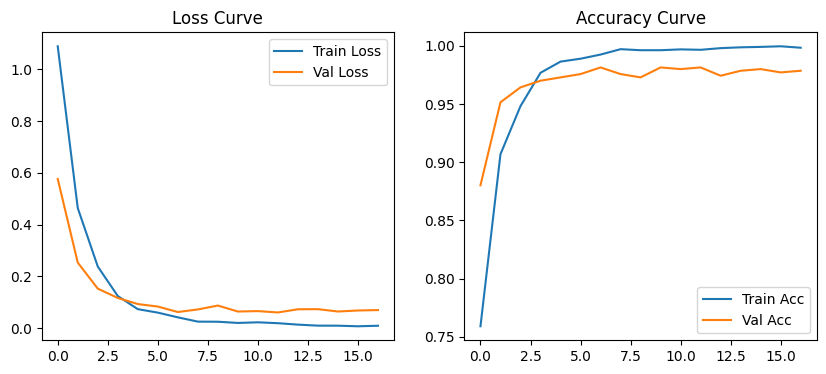


Training completed in 252.90 seconds.

=== Train Classification Report ===
              precision    recall  f1-score   support

      glioma     1.0000    1.0000    1.0000      1296
  meningioma     0.9985    1.0000    0.9992      1316
     notumor     1.0000    0.9994    0.9997      1600
   pituitary     1.0000    0.9993    0.9996      1405

    accuracy                         0.9996      5617
   macro avg     0.9996    0.9997    0.9996      5617
weighted avg     0.9996    0.9996    0.9996      5617


=== Validation Classification Report ===
              precision    recall  f1-score   support

      glioma     0.9815    0.9815    0.9815       162
  meningioma     0.9750    0.9512    0.9630       164
     notumor     0.9852    1.0000    0.9926       200
   pituitary     0.9830    0.9886    0.9858       175

    accuracy                         0.9815       701
   macro avg     0.9812    0.9803    0.9807       701
weighted avg     0.9814    0.9815    0.9814       701


=== Test Cl

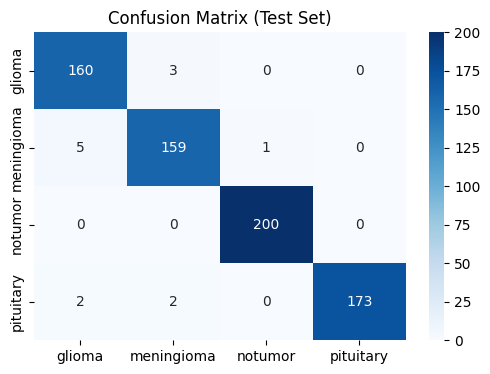


Cohen’s Kappa: 0.9754
Mean PPV: 0.9807
Mean NPV: 0.9940
Mean Sensitivity: 0.9807
Mean Specificity: 0.9940


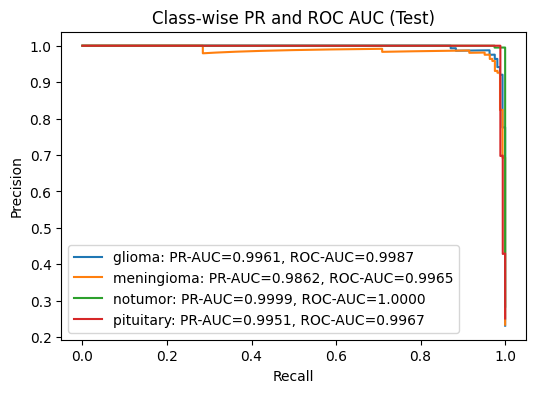


Accuracy: 0.9816
95% Confidence Interval: (0.9716, 0.9901)

GPU Memory Used: 39.00 MB
RAM Used: 2.24 GB
Inference Time: 1.17 seconds
Training Time: 252.90 seconds

Permutation Test p-value (accuracy vs random): 0.0000


In [ ]:
# ============================================================
# 🧠 Brain MRI Tumor Classification - ShuffleNetV2
# ============================================================

import os, time, psutil, torch, numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, cohen_kappa_score,
    roc_auc_score, precision_recall_curve, auc
)
from scipy import stats

# ============================================================
# 1️⃣ Setup
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

batch_size = 32
train_dir = "/kaggle/working/brain_split/train"
val_dir = "/kaggle/working/brain_split/val"
test_dir = "/kaggle/working/brain_split/test"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_ds = datasets.ImageFolder(train_dir, transform=transform)
val_ds = datasets.ImageFolder(val_dir, transform=transform)
test_ds = datasets.ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

class_names = train_ds.classes
num_classes = len(class_names)
print("Classes:", class_names)

# ============================================================
# 2️⃣ ShuffleNetV2 Baseline Model
# ============================================================

class ShuffleNetV2_Baseline(nn.Module):
    def __init__(self, num_classes=4, dropout=0.3):
        super().__init__()
        base_model = models.shufflenet_v2_x1_0(weights='IMAGENET1K_V1')
        self.features = nn.Sequential(*(list(base_model.children())[:-1]))
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(1024, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.mean(dim=[2,3])
        x = self.fc(x)
        return x

model = ShuffleNetV2_Baseline(num_classes=num_classes).to(device)

# ============================================================
# 3️⃣ Training Setup
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5, verbose=True)

epochs = 50
patience = 5
best_val_loss = float('inf')
patience_counter = 0

# ============================================================
# 4️⃣ Training Loop
# ============================================================

def train_model(model):
    global best_val_loss, patience_counter
    start_time = time.time()

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, total_train = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * imgs.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()
            total_train += labels.size(0)

        avg_train_loss = train_loss / total_train
        train_accuracy = train_correct / total_train

        model.eval()
        val_loss, val_correct, total_val = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                total_val += labels.size(0)

        avg_val_loss = val_loss / total_val
        val_accuracy = val_correct / total_val

        scheduler.step(avg_val_loss)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
              f"Train Acc: {train_accuracy:.4f} | Val Acc: {val_accuracy:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), "shuffle_baseline_model.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    end_time = time.time()
    training_time = end_time - start_time

    # Plot curves
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.legend(); plt.title("Loss Curve")
    plt.subplot(1,2,2)
    plt.plot(train_accs, label='Train Acc')
    plt.plot(val_accs, label='Val Acc')
    plt.legend(); plt.title("Accuracy Curve")
    plt.show()

    print(f"\nTraining completed in {training_time:.2f} seconds.")
    return training_time

# ============================================================
# 5️⃣ Simple Evaluation Function
# ============================================================

def evaluate_simple(model, loader, name="Set"):
    y_true, y_pred = [], []
    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.cpu().numpy())
    print(f"\n=== {name} Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# ============================================================
# 6️⃣ Test Evaluation
# ============================================================

def evaluate_test(model, loader, training_time):
    y_true, y_pred, y_prob = [], [], []
    start_inf = time.time()

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = F.softmax(outputs, dim=1)
            preds = probs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.numpy())
            y_prob.extend(probs.cpu().numpy())

    end_inf = time.time()
    inference_time = end_inf - start_inf

    print("\n=== Test Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix (Test Set)")
    plt.show()

    kappa = cohen_kappa_score(y_true, y_pred)
    print(f"\nCohen’s Kappa: {kappa:.4f}")

    metrics = []
    for i in range(num_classes):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - (tp + fn + fp)
        ppv = tp / (tp + fp + 1e-8)
        npv = tn / (tn + fn + 1e-8)
        sens = tp / (tp + fn + 1e-8)
        spec = tn / (tn + fp + 1e-8)
        metrics.append((ppv, npv, sens, spec))

    metrics = np.array(metrics)
    mean_ppv, mean_npv, mean_sens, mean_spec = metrics.mean(axis=0)
    print(f"Mean PPV: {mean_ppv:.4f}")
    print(f"Mean NPV: {mean_npv:.4f}")
    print(f"Mean Sensitivity: {mean_sens:.4f}")
    print(f"Mean Specificity: {mean_spec:.4f}")

    y_true_bin = np.eye(num_classes)[y_true]
    plt.figure(figsize=(6, 4))
    for i, c in enumerate(class_names):
        roc_auc = roc_auc_score(y_true_bin[:, i], np.array(y_prob)[:, i])
        prec, rec, _ = precision_recall_curve(y_true_bin[:, i], np.array(y_prob)[:, i])
        pr_auc = auc(rec, prec)
        plt.plot(rec, prec, label=f'{c}: PR-AUC={pr_auc:.4f}, ROC-AUC={roc_auc:.4f}')
    plt.title("Class-wise PR and ROC AUC (Test)")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.show()

    acc = np.mean(np.array(y_true) == np.array(y_pred))
    ci_low, ci_high = stats.binom.interval(0.95, len(y_true), acc)
    ci_low /= len(y_true)
    ci_high /= len(y_true)
    print(f"\nAccuracy: {acc:.4f}")
    print(f"95% Confidence Interval: ({ci_low:.4f}, {ci_high:.4f})")

    try:
        gpu_mem = torch.cuda.memory_allocated() / (1024 ** 2)
    except:
        gpu_mem = 0
    ram_usage = psutil.virtual_memory().used / (1024**3)
    print(f"\nGPU Memory Used: {gpu_mem:.2f} MB")
    print(f"RAM Used: {ram_usage:.2f} GB")
    print(f"Inference Time: {inference_time:.2f} seconds")
    print(f"Training Time: {training_time:.2f} seconds")

    # ===================== Permutation Test =====================
    n_permutations = 100
    perm_accs = []
    y_true_arr = np.array(y_true)
    for _ in range(n_permutations):
        perm_labels = np.random.permutation(y_true_arr)
        perm_accs.append(np.mean(perm_labels == y_pred))
    perm_accs = np.array(perm_accs)
    p_value = np.mean(perm_accs >= acc)
    print(f"\nPermutation Test p-value (accuracy vs random): {p_value:.4f}")

# ============================================================
# 7️⃣ Train + Evaluate
# ============================================================

training_time = train_model(model)
model.load_state_dict(torch.load("shuffle_baseline_model.pth"))

evaluate_simple(model, train_loader, "Train")
evaluate_simple(model, val_loader, "Validation")
evaluate_test(model, test_loader, training_time)


Using device: cuda


Downloading: "https://download.pytorch.org/models/squeezenet1_1-b8a52dc0.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_1-b8a52dc0.pth


Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


100%|██████████| 4.73M/4.73M [00:00<00:00, 91.5MB/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/50] | Train Loss: 0.7212 | Val Loss: 0.3541 | Train Acc: 0.7235 | Val Acc: 0.8944
Epoch [2/50] | Train Loss: 0.3585 | Val Loss: 0.2567 | Train Acc: 0.8709 | Val Acc: 0.9215
Epoch [3/50] | Train Loss: 0.2679 | Val Loss: 0.1664 | Train Acc: 0.9035 | Val Acc: 0.9401
Epoch [4/50] | Train Loss: 0.2156 | Val Loss: 0.1826 | Train Acc: 0.9242 | Val Acc: 0.9401
Epoch [5/50] | Train Loss: 0.1765 | Val Loss: 0.2025 | Train Acc: 0.9386 | Val Acc: 0.9272
Epoch [6/50] | Train Loss: 0.1452 | Val Loss: 0.1251 | Train Acc: 0.9482 | Val Acc: 0.9572
Epoch [7/50] | Train Loss: 0.1409 | Val Loss: 0.0938 | Train Acc: 0.9482 | Val Acc: 0.9686
Epoch [8/50] | Train Loss: 0.1008 | Val Loss: 0.1495 | Train Acc: 0.9653 | Val Acc: 0.9458
Epoch [9/50] | Train Loss: 0.1019 | Val Loss: 0.0991 | Train Acc: 0.9640 | Val Acc: 0.9629
Epoch [10/50] | Train Loss: 0.0835 | Val Loss: 0.1021 | Train Acc: 0.9703 | Val Acc: 0.9643
Epoch [11/50] | Train Loss: 0.0559 | Val Loss: 0.0756 | Train Acc: 0.9801 | Val Acc: 0.97

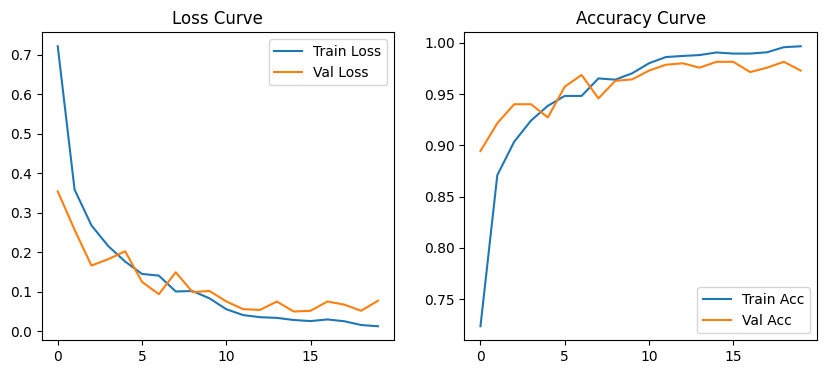


Training completed in 285.57 seconds.

=== Train Classification Report ===
              precision    recall  f1-score   support

      glioma     0.9908    1.0000    0.9954      1296
  meningioma     0.9992    0.9909    0.9950      1316
     notumor     1.0000    1.0000    1.0000      1600
   pituitary     0.9993    0.9986    0.9989      1405

    accuracy                         0.9975      5617
   macro avg     0.9973    0.9974    0.9973      5617
weighted avg     0.9975    0.9975    0.9975      5617


=== Validation Classification Report ===
              precision    recall  f1-score   support

      glioma     0.9641    0.9938    0.9787       162
  meningioma     0.9871    0.9329    0.9592       164
     notumor     0.9852    1.0000    0.9926       200
   pituitary     0.9886    0.9943    0.9915       175

    accuracy                         0.9815       701
   macro avg     0.9813    0.9803    0.9805       701
weighted avg     0.9816    0.9815    0.9813       701


=== Test Cl

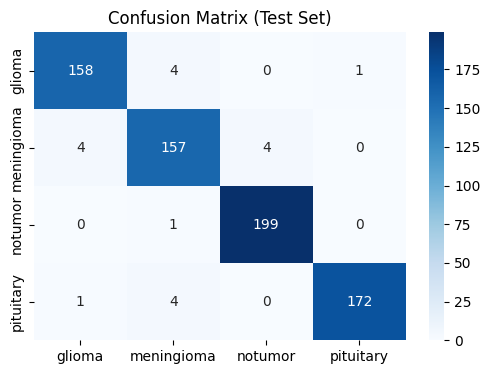


Cohen’s Kappa: 0.9640
Mean PPV: 0.9724
Mean NPV: 0.9911
Mean Sensitivity: 0.9719
Mean Specificity: 0.9911


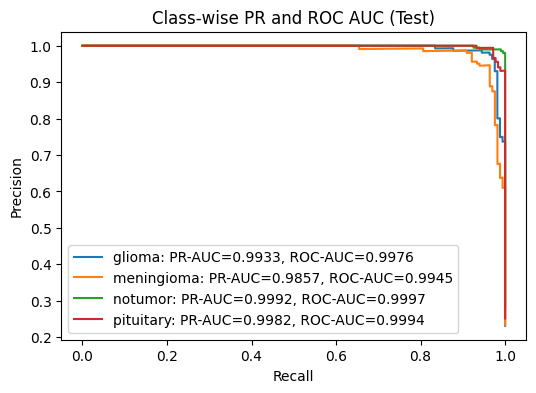


Accuracy: 0.9730
95% Confidence Interval: (0.9603, 0.9844)

GPU Memory Used: 35.14 MB
RAM Used: 2.30 GB
Inference Time: 1.17 seconds
Training Time: 285.57 seconds

Permutation Test p-value (accuracy vs random): 0.0000


In [ ]:
# ============================================================
# 🧠 Brain MRI Tumor Classification - SqueezeNet
# ============================================================

import os, time, psutil, torch, numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, cohen_kappa_score,
    roc_auc_score, precision_recall_curve, auc
)
from scipy import stats

# ============================================================
# 1️⃣ Setup
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

batch_size = 32
train_dir = "/kaggle/working/brain_split/train"
val_dir = "/kaggle/working/brain_split/val"
test_dir = "/kaggle/working/brain_split/test"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_ds = datasets.ImageFolder(train_dir, transform=transform)
val_ds = datasets.ImageFolder(val_dir, transform=transform)
test_ds = datasets.ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

class_names = train_ds.classes
num_classes = len(class_names)
print("Classes:", class_names)

# ============================================================
# 2️⃣ Plain SqueezeNet (No SE Block)
# ============================================================

class SqueezeNet_Baseline(nn.Module):
    def __init__(self, num_classes=4, dropout=0.3):
        super().__init__()
        base_model = models.squeezenet1_1(weights='IMAGENET1K_V1')
        self.features = base_model.features
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.mean(dim=[2, 3])
        x = self.fc(x)
        return x

model = SqueezeNet_Baseline(num_classes=num_classes).to(device)

# ============================================================
# 3️⃣ Training Setup
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5, verbose=True)

epochs = 50
patience = 5
best_val_loss = float('inf')
patience_counter = 0

# ============================================================
# 4️⃣ Evaluation Helper
# ============================================================

def evaluate_simple(model, loader, name="Set"):
    y_true, y_pred = [], []
    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.cpu().numpy())
    print(f"\n=== {name} Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# ============================================================
# 5️⃣ Training Loop
# ============================================================

def train_model(model):
    global best_val_loss, patience_counter
    start_time = time.time()

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, total_train = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * imgs.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()
            total_train += labels.size(0)

        avg_train_loss = train_loss / total_train
        train_accuracy = train_correct / total_train

        model.eval()
        val_loss, val_correct, total_val = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                total_val += labels.size(0)

        avg_val_loss = val_loss / total_val
        val_accuracy = val_correct / total_val

        scheduler.step(avg_val_loss)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
              f"Train Acc: {train_accuracy:.4f} | Val Acc: {val_accuracy:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), "best_squeezenet_baseline.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    end_time = time.time()
    training_time = end_time - start_time

    # Plot curves
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.legend(); plt.title("Loss Curve")
    plt.subplot(1,2,2)
    plt.plot(train_accs, label='Train Acc')
    plt.plot(val_accs, label='Val Acc')
    plt.legend(); plt.title("Accuracy Curve")
    plt.show()

    print(f"\nTraining completed in {training_time:.2f} seconds.")
    return training_time

# ============================================================
# 6️⃣ Training + Validation Reports
# ============================================================

training_time = train_model(model)
model.load_state_dict(torch.load("best_squeezenet_baseline.pth"))

evaluate_simple(model, train_loader, "Train")
evaluate_simple(model, val_loader, "Validation")

# ============================================================
# 7️⃣ Test Evaluation (Detailed + Permutation p-value)
# ============================================================

def evaluate_test(model, loader, training_time):
    y_true, y_pred, y_prob = [], [], []
    start_inf = time.time()

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = F.softmax(outputs, dim=1)
            preds = probs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.numpy())
            y_prob.extend(probs.cpu().numpy())

    end_inf = time.time()
    inference_time = end_inf - start_inf

    print("\n=== Test Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix (Test Set)")
    plt.show()

    kappa = cohen_kappa_score(y_true, y_pred)
    print(f"\nCohen’s Kappa: {kappa:.4f}")

    metrics = []
    for i in range(num_classes):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - (tp + fn + fp)
        ppv = tp / (tp + fp + 1e-8)
        npv = tn / (tn + fn + 1e-8)
        sens = tp / (tp + fn + 1e-8)
        spec = tn / (tn + fp + 1e-8)
        metrics.append((ppv, npv, sens, spec))

    metrics = np.array(metrics)
    mean_ppv, mean_npv, mean_sens, mean_spec = metrics.mean(axis=0)
    print(f"Mean PPV: {mean_ppv:.4f}")
    print(f"Mean NPV: {mean_npv:.4f}")
    print(f"Mean Sensitivity: {mean_sens:.4f}")
    print(f"Mean Specificity: {mean_spec:.4f}")

    y_true_bin = np.eye(num_classes)[y_true]
    plt.figure(figsize=(6, 4))
    for i, c in enumerate(class_names):
        roc_auc = roc_auc_score(y_true_bin[:, i], np.array(y_prob)[:, i])
        prec, rec, _ = precision_recall_curve(y_true_bin[:, i], np.array(y_prob)[:, i])
        pr_auc = auc(rec, prec)
        plt.plot(rec, prec, label=f'{c}: PR-AUC={pr_auc:.4f}, ROC-AUC={roc_auc:.4f}')
    plt.title("Class-wise PR and ROC AUC (Test)")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.show()

    acc = np.mean(np.array(y_true) == np.array(y_pred))
    ci_low, ci_high = stats.binom.interval(0.95, len(y_true), acc)
    ci_low /= len(y_true)
    ci_high /= len(y_true)
    print(f"\nAccuracy: {acc:.4f}")
    print(f"95% Confidence Interval: ({ci_low:.4f}, {ci_high:.4f})")

    try:
        gpu_mem = torch.cuda.memory_allocated() / (1024 ** 2)
    except:
        gpu_mem = 0
    ram_usage = psutil.virtual_memory().used / (1024**3)
    print(f"\nGPU Memory Used: {gpu_mem:.2f} MB")
    print(f"RAM Used: {ram_usage:.2f} GB")
    print(f"Inference Time: {inference_time:.2f} seconds")
    print(f"Training Time: {training_time:.2f} seconds")

    # ===================== Permutation Test =====================
    n_permutations = 100
    perm_accs = []
    y_true_arr = np.array(y_true)
    for _ in range(n_permutations):
        perm_labels = np.random.permutation(y_true_arr)
        perm_accs.append(np.mean(perm_labels == y_pred))
    perm_accs = np.array(perm_accs)
    p_value = np.mean(perm_accs >= acc)
    print(f"\nPermutation Test p-value (accuracy vs random): {p_value:.4f}")

# ============================================================
# 8️⃣ Evaluate Test Set
# ============================================================

evaluate_test(model, test_loader, training_time)


Using device: cuda


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


100%|██████████| 13.6M/13.6M [00:00<00:00, 163MB/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/50] | Train Loss: 0.3144 | Val Loss: 0.1195 | Train Acc: 0.8864 | Val Acc: 0.9615
Epoch [2/50] | Train Loss: 0.0788 | Val Loss: 0.0607 | Train Acc: 0.9735 | Val Acc: 0.9757
Epoch [3/50] | Train Loss: 0.0347 | Val Loss: 0.0433 | Train Acc: 0.9890 | Val Acc: 0.9843
Epoch [4/50] | Train Loss: 0.0251 | Val Loss: 0.0562 | Train Acc: 0.9918 | Val Acc: 0.9857
Epoch [5/50] | Train Loss: 0.0174 | Val Loss: 0.0320 | Train Acc: 0.9950 | Val Acc: 0.9886
Epoch [6/50] | Train Loss: 0.0093 | Val Loss: 0.0308 | Train Acc: 0.9975 | Val Acc: 0.9857
Epoch [7/50] | Train Loss: 0.0171 | Val Loss: 0.0336 | Train Acc: 0.9945 | Val Acc: 0.9886
Epoch [8/50] | Train Loss: 0.0193 | Val Loss: 0.0305 | Train Acc: 0.9947 | Val Acc: 0.9886
Epoch [9/50] | Train Loss: 0.0177 | Val Loss: 0.0248 | Train Acc: 0.9943 | Val Acc: 0.9914
Epoch [10/50] | Train Loss: 0.0089 | Val Loss: 0.0495 | Train Acc: 0.9972 | Val Acc: 0.9829
Epoch [11/50] | Train Loss: 0.0059 | Val Loss: 0.0175 | Train Acc: 0.9979 | Val Acc: 0.99

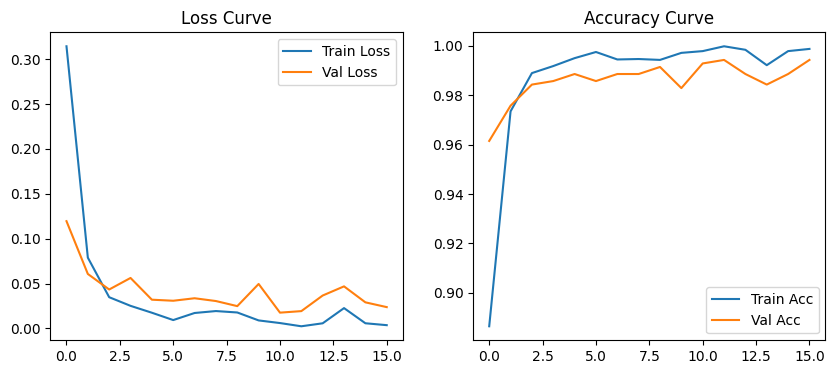


Training completed in 358.61 seconds.

=== Train Classification Report ===
              precision    recall  f1-score   support

      glioma     1.0000    1.0000    1.0000      1296
  meningioma     1.0000    1.0000    1.0000      1316
     notumor     1.0000    1.0000    1.0000      1600
   pituitary     1.0000    1.0000    1.0000      1405

    accuracy                         1.0000      5617
   macro avg     1.0000    1.0000    1.0000      5617
weighted avg     1.0000    1.0000    1.0000      5617


=== Validation Classification Report ===
              precision    recall  f1-score   support

      glioma     0.9939    1.0000    0.9969       162
  meningioma     0.9877    0.9817    0.9847       164
     notumor     0.9901    1.0000    0.9950       200
   pituitary     1.0000    0.9886    0.9943       175

    accuracy                         0.9929       701
   macro avg     0.9929    0.9926    0.9927       701
weighted avg     0.9929    0.9929    0.9929       701


=== Test Cl

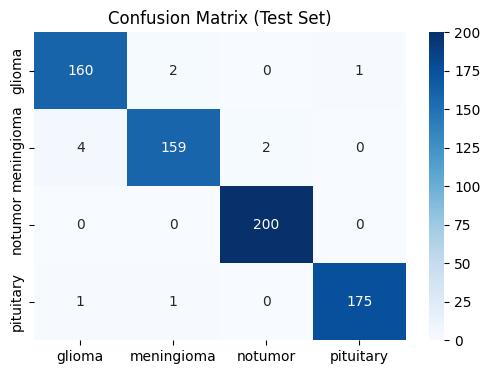


Cohen’s Kappa: 0.9791
Mean PPV: 0.9839
Mean NPV: 0.9949
Mean Sensitivity: 0.9835
Mean Specificity: 0.9948


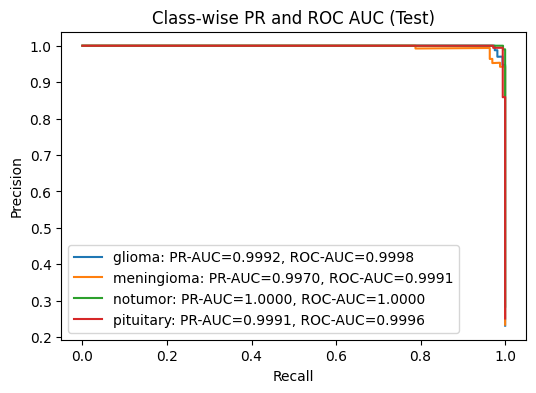


Accuracy: 0.9844
95% Confidence Interval: (0.9745, 0.9929)


Permutation test: 100%|██████████| 1000/1000 [00:00<00:00, 16697.14it/s]

Permutation-based accuracy p-value: 0.0000

GPU Memory Used: 58.86 MB
RAM Used: 2.32 GB
Inference Time: 1.34 seconds
Training Time: 358.61 seconds


In [ ]:
# ============================================================
# 🧠 Brain MRI Tumor Classification - MobileNetV2
# ============================================================

import os, time, psutil, torch, numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score, roc_auc_score, precision_recall_curve, auc
from scipy import stats
from tqdm import tqdm

# ============================================================
# 1️⃣ Setup
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

batch_size = 32
train_dir = "/kaggle/working/brain_split/train"
val_dir = "/kaggle/working/brain_split/val"
test_dir = "/kaggle/working/brain_split/test"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_ds = datasets.ImageFolder(train_dir, transform=transform)
val_ds = datasets.ImageFolder(val_dir, transform=transform)
test_ds = datasets.ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

class_names = train_ds.classes
num_classes = len(class_names)
print("Classes:", class_names)

# ============================================================
# 2️⃣ MobileNetV2 (Without SE)
# ============================================================

class MobileNetV2_Baseline(nn.Module):
    def __init__(self, num_classes=4, dropout=0.3):
        super().__init__()
        base_model = models.mobilenet_v2(weights='IMAGENET1K_V1')
        self.features = base_model.features
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(1280, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.mean(dim=[2,3])
        x = self.fc(x)
        return x

model = MobileNetV2_Baseline(num_classes=num_classes).to(device)

# ============================================================
# 3️⃣ Training Setup
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5, verbose=True)

epochs = 50
patience = 5
best_val_loss = float('inf')
patience_counter = 0

# ============================================================
# 4️⃣ Training Loop
# ============================================================

def evaluate_simple(model, loader, name="Set"):
    y_true, y_pred = [], []
    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.cpu().numpy())
    print(f"\n=== {name} Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

def train_model(model):
    global best_val_loss, patience_counter
    start_time = time.time()

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, total_train = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * imgs.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()
            total_train += labels.size(0)

        avg_train_loss = train_loss / total_train
        train_accuracy = train_correct / total_train

        model.eval()
        val_loss, val_correct, total_val = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                total_val += labels.size(0)

        avg_val_loss = val_loss / total_val
        val_accuracy = val_correct / total_val

        scheduler.step(avg_val_loss)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
              f"Train Acc: {train_accuracy:.4f} | Val Acc: {val_accuracy:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), "best_mobilenetv2_baseline.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    end_time = time.time()
    training_time = end_time - start_time

    # Plot curves
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.legend(); plt.title("Loss Curve")
    plt.subplot(1,2,2)
    plt.plot(train_accs, label='Train Acc')
    plt.plot(val_accs, label='Val Acc')
    plt.legend(); plt.title("Accuracy Curve")
    plt.show()

    print(f"\nTraining completed in {training_time:.2f} seconds.")
    return training_time

# ============================================================
# 5️⃣ Training + Validation Reports
# ============================================================

training_time = train_model(model)
model.load_state_dict(torch.load("best_mobilenetv2_baseline.pth"))

evaluate_simple(model, train_loader, "Train")
evaluate_simple(model, val_loader, "Validation")

# ============================================================
# 6️⃣ Test Evaluation (Detailed) + Permutation Accuracy
# ============================================================

def evaluate_test(model, loader, n_permutations=1000):
    y_true, y_pred, y_prob = [], [], []
    start_inf = time.time()

    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = F.softmax(outputs, dim=1)
            preds = probs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.numpy())
            y_prob.extend(probs.cpu().numpy())

    end_inf = time.time()
    inference_time = end_inf - start_inf

    # --- Classification Report ---
    print("\n=== Test Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix (Test Set)")
    plt.show()

    # --- Cohen's Kappa ---
    kappa = cohen_kappa_score(y_true, y_pred)
    print(f"\nCohen’s Kappa: {kappa:.4f}")

    # --- Mean PPV, NPV, Sensitivity, Specificity ---
    metrics = []
    for i in range(num_classes):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - (tp + fn + fp)
        ppv = tp / (tp + fp + 1e-8)
        npv = tn / (tn + fn + 1e-8)
        sens = tp / (tp + fn + 1e-8)
        spec = tn / (tn + fp + 1e-8)
        metrics.append((ppv, npv, sens, spec))
    metrics = np.array(metrics)
    mean_ppv, mean_npv, mean_sens, mean_spec = metrics.mean(axis=0)
    print(f"Mean PPV: {mean_ppv:.4f}")
    print(f"Mean NPV: {mean_npv:.4f}")
    print(f"Mean Sensitivity: {mean_sens:.4f}")
    print(f"Mean Specificity: {mean_spec:.4f}")

    # --- ROC & PR Curves ---
    y_true_bin = np.eye(num_classes)[y_true]
    plt.figure(figsize=(6, 4))
    for i, c in enumerate(class_names):
        roc_auc = roc_auc_score(y_true_bin[:, i], np.array(y_prob)[:, i])
        prec, rec, _ = precision_recall_curve(y_true_bin[:, i], np.array(y_prob)[:, i])
        pr_auc = auc(rec, prec)
        plt.plot(rec, prec, label=f'{c}: PR-AUC={pr_auc:.4f}, ROC-AUC={roc_auc:.4f}')
    plt.title("Class-wise PR and ROC AUC (Test)")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.show()

    # --- Accuracy and 95% CI ---
    acc = np.mean(np.array(y_true) == np.array(y_pred))
    ci_low, ci_high = stats.binom.interval(0.95, len(y_true), acc)
    ci_low /= len(y_true)
    ci_high /= len(y_true)
    print(f"\nAccuracy: {acc:.4f}")
    print(f"95% Confidence Interval: ({ci_low:.4f}, {ci_high:.4f})")

    # --- Permutation-based accuracy ---
    perm_acc = []
    y_true_arr = np.array(y_true)
    for _ in tqdm(range(n_permutations), desc="Permutation test"):
        y_perm = np.random.permutation(y_true_arr)
        perm_acc.append(np.mean(y_perm == np.array(y_pred)))
    perm_acc = np.array(perm_acc)
    p_value = np.mean(perm_acc >= acc)
    print(f"Permutation-based accuracy p-value: {p_value:.4f}")

    # --- Resource Usage ---
    try:
        gpu_mem = torch.cuda.memory_allocated() / (1024 ** 2)
    except:
        gpu_mem = 0
    ram_usage = psutil.virtual_memory().used / (1024**3)
    print(f"\nGPU Memory Used: {gpu_mem:.2f} MB")
    print(f"RAM Used: {ram_usage:.2f} GB")
    print(f"Inference Time: {inference_time:.2f} seconds")
    print(f"Training Time: {training_time:.2f} seconds")

# ============================================================
# Run Test Evaluation
# ============================================================

evaluate_test(model, test_loader, n_permutations=1000)


Using device: cuda
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/50] | Train Loss: 0.2647 | Val Loss: 0.1052 | Train Acc: 0.9092 | Val Acc: 0.9615
Epoch [2/50] | Train Loss: 0.0592 | Val Loss: 0.1134 | Train Acc: 0.9836 | Val Acc: 0.9615
Epoch [3/50] | Train Loss: 0.0239 | Val Loss: 0.0663 | Train Acc: 0.9943 | Val Acc: 0.9815
Epoch [4/50] | Train Loss: 0.0206 | Val Loss: 0.0771 | Train Acc: 0.9945 | Val Acc: 0.9743
Epoch [5/50] | Train Loss: 0.0243 | Val Loss: 0.0543 | Train Acc: 0.9936 | Val Acc: 0.9786
Epoch [6/50] | Train Loss: 0.0173 | Val Loss: 0.0160 | Train Acc: 0.9941 | Val Acc: 0.9957
Epoch [7/50] | Train Loss: 0.0148 | Val Loss: 0.0273 | Train Acc: 0.9963 | Val Acc: 0.9857
Epoch [8/50] | Train Loss: 0.0061 | Val Loss: 0.0200 | Train Acc: 0.9989 | Val Acc: 0.9929
Epoch [9/50] | Train Loss: 0.0136 | Val Loss: 0.0244 | Train Acc: 0.9957 | Val Acc: 0.9943
Epoch [10/50] | Train Loss: 0.0048 | Val Loss: 0.0170 | Train Acc: 0.9995 | Val Acc: 0.9943
Epoch [11/50] | Train Loss: 0.0017 | Val Loss: 0.0217 | Train Acc: 1.0000 | Val Acc: 0.99

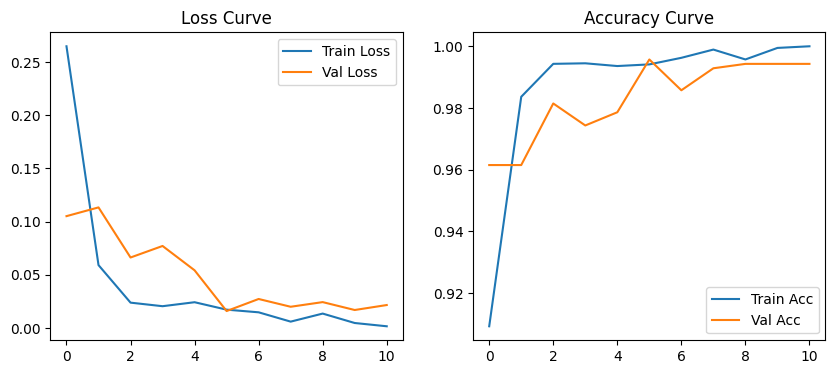


Training completed in 673.81 seconds.

=== Train Classification Report ===
              precision    recall  f1-score   support

      glioma     0.9985    1.0000    0.9992      1296
  meningioma     1.0000    0.9985    0.9992      1316
     notumor     1.0000    1.0000    1.0000      1600
   pituitary     0.9993    0.9993    0.9993      1405

    accuracy                         0.9995      5617
   macro avg     0.9994    0.9994    0.9994      5617
weighted avg     0.9995    0.9995    0.9995      5617


=== Validation Classification Report ===
              precision    recall  f1-score   support

      glioma     0.9939    1.0000    0.9969       162
  meningioma     1.0000    0.9817    0.9908       164
     notumor     0.9950    1.0000    0.9975       200
   pituitary     0.9943    1.0000    0.9972       175

    accuracy                         0.9957       701
   macro avg     0.9958    0.9954    0.9956       701
weighted avg     0.9957    0.9957    0.9957       701


=== Test Cl

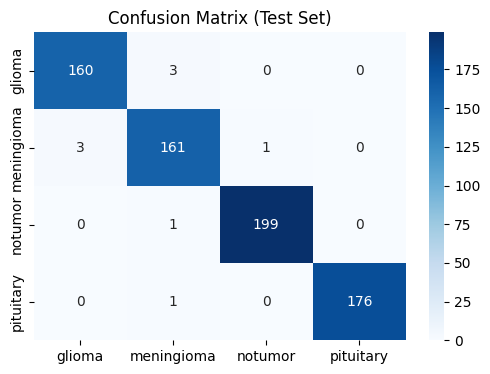


Cohen’s Kappa: 0.9829
Mean PPV: 0.9866
Mean NPV: 0.9958
Mean Sensitivity: 0.9867
Mean Specificity: 0.9958


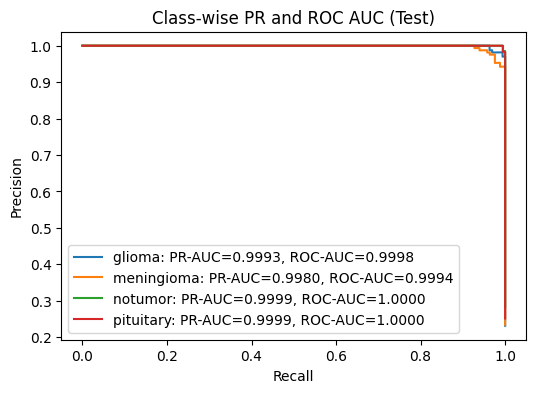


Accuracy: 0.9872
95% Confidence Interval: (0.9787, 0.9943)


Permutation test: 100%|██████████| 1000/1000 [00:00<00:00, 13587.91it/s]

Permutation-based accuracy p-value: 0.0000

GPU Memory Used: 296.52 MB
RAM Used: 2.33 GB
Inference Time: 2.98 seconds
Training Time: 673.81 seconds


In [ ]:
# ============================================================
# 🧠 Brain MRI Tumor Classification - DenseNet201
# ============================================================

import os, time, psutil, torch, numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score, roc_auc_score, precision_recall_curve, auc
from scipy import stats
from tqdm import tqdm

# ============================================================
# 1️⃣ Setup
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

batch_size = 32
train_dir = "/kaggle/working/brain_split/train"
val_dir = "/kaggle/working/brain_split/val"
test_dir = "/kaggle/working/brain_split/test"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_ds = datasets.ImageFolder(train_dir, transform=transform)
val_ds = datasets.ImageFolder(val_dir, transform=transform)
test_ds = datasets.ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

class_names = train_ds.classes
num_classes = len(class_names)
print("Classes:", class_names)

# ============================================================
# 2️⃣ DenseNet201
# ============================================================

class DenseNet201(nn.Module):
    def __init__(self, num_classes=4, dropout=0.3):
        super().__init__()
        base_model = models.densenet201(weights='IMAGENET1K_V1')
        self.features = base_model.features
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(1920, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = F.relu(x, inplace=True)
        x = x.mean(dim=[2,3])
        x = self.fc(x)
        return x

model = DenseNet201(num_classes=num_classes).to(device)

# ============================================================
# 3️⃣ Training Setup
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5, verbose=True)

epochs = 50
patience = 5
best_val_loss = float('inf')
patience_counter = 0

# ============================================================
# 4️⃣ Training Loop
# ============================================================

def evaluate_simple(model, loader, name="Set"):
    y_true, y_pred = [], []
    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.cpu().numpy())
    print(f"\n=== {name} Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

def train_model(model):
    global best_val_loss, patience_counter
    start_time = time.time()
    train_losses, val_losses, train_accs, val_accs = [], [], [], []

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, total_train = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * imgs.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()
            total_train += labels.size(0)

        avg_train_loss = train_loss / total_train
        train_accuracy = train_correct / total_train

        model.eval()
        val_loss, val_correct, total_val = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                total_val += labels.size(0)

        avg_val_loss = val_loss / total_val
        val_accuracy = val_correct / total_val

        scheduler.step(avg_val_loss)
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | Train Acc: {train_accuracy:.4f} | Val Acc: {val_accuracy:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), "best_densenet201.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    end_time = time.time()
    training_time = end_time - start_time

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.legend(); plt.title("Loss Curve")
    plt.subplot(1,2,2)
    plt.plot(train_accs, label='Train Acc')
    plt.plot(val_accs, label='Val Acc')
    plt.legend(); plt.title("Accuracy Curve")
    plt.show()

    print(f"\nTraining completed in {training_time:.2f} seconds.")
    return training_time

# ============================================================
# 5️⃣ Train + Validation Reports
# ============================================================

training_time = train_model(model)
model.load_state_dict(torch.load("best_densenet201.pth"))

evaluate_simple(model, train_loader, "Train")
evaluate_simple(model, val_loader, "Validation")

# ============================================================
# 6️⃣ Test Evaluation (Detailed) + Permutation Accuracy
# ============================================================

def evaluate_test(model, loader, n_permutations=1000):
    y_true, y_pred, y_prob = [], [], []
    start_inf = time.time()

    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = F.softmax(outputs, dim=1)
            preds = probs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.numpy())
            y_prob.extend(probs.cpu().numpy())

    end_inf = time.time()
    inference_time = end_inf - start_inf

    print("\n=== Test Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix (Test Set)")
    plt.show()

    kappa = cohen_kappa_score(y_true, y_pred)
    print(f"\nCohen’s Kappa: {kappa:.4f}")

    metrics = []
    for i in range(num_classes):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - (tp + fn + fp)
        ppv = tp / (tp + fp + 1e-8)
        npv = tn / (tn + fn + 1e-8)
        sens = tp / (tp + fn + 1e-8)
        spec = tn / (tn + fp + 1e-8)
        metrics.append((ppv, npv, sens, spec))
    metrics = np.array(metrics)
    mean_ppv, mean_npv, mean_sens, mean_spec = metrics.mean(axis=0)
    print(f"Mean PPV: {mean_ppv:.4f}")
    print(f"Mean NPV: {mean_npv:.4f}")
    print(f"Mean Sensitivity: {mean_sens:.4f}")
    print(f"Mean Specificity: {mean_spec:.4f}")

    y_true_bin = np.eye(num_classes)[y_true]
    plt.figure(figsize=(6, 4))
    for i, c in enumerate(class_names):
        roc_auc = roc_auc_score(y_true_bin[:, i], np.array(y_prob)[:, i])
        prec, rec, _ = precision_recall_curve(y_true_bin[:, i], np.array(y_prob)[:, i])
        pr_auc = auc(rec, prec)
        plt.plot(rec, prec, label=f'{c}: PR-AUC={pr_auc:.4f}, ROC-AUC={roc_auc:.4f}')
    plt.title("Class-wise PR and ROC AUC (Test)")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.show()

    acc = np.mean(np.array(y_true) == np.array(y_pred))
    ci_low, ci_high = stats.binom.interval(0.95, len(y_true), acc)
    ci_low /= len(y_true)
    ci_high /= len(y_true)
    print(f"\nAccuracy: {acc:.4f}")
    print(f"95% Confidence Interval: ({ci_low:.4f}, {ci_high:.4f})")

    perm_acc = []
    y_true_arr = np.array(y_true)
    for _ in tqdm(range(n_permutations), desc="Permutation test"):
        y_perm = np.random.permutation(y_true_arr)
        perm_acc.append(np.mean(y_perm == np.array(y_pred)))
    perm_acc = np.array(perm_acc)
    p_value = np.mean(perm_acc >= acc)
    print(f"Permutation-based accuracy p-value: {p_value:.4f}")

    try:
        gpu_mem = torch.cuda.memory_allocated() / (1024 ** 2)
    except:
        gpu_mem = 0
    ram_usage = psutil.virtual_memory().used / (1024**3)
    print(f"\nGPU Memory Used: {gpu_mem:.2f} MB")
    print(f"RAM Used: {ram_usage:.2f} GB")
    print(f"Inference Time: {inference_time:.2f} seconds")
    print(f"Training Time: {training_time:.2f} seconds")

# ============================================================
# Run Test Evaluation
# ============================================================

evaluate_test(model, test_loader, n_permutations=1000)


Using device: cuda
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


/usr/local/lib/python3.11/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [2/50] | Train Loss: 0.0651 | Val Loss: 0.1240 | Train Acc: 0.9804 | Val Acc: 0.9586
Epoch [3/50] | Train Loss: 0.0271 | Val Loss: 0.0476 | Train Acc: 0.9932 | Val Acc: 0.9843
Epoch [4/50] | Train Loss: 0.0118 | Val Loss: 0.0376 | Train Acc: 0.9972 | Val Acc: 0.9886
Epoch [5/50] | Train Loss: 0.0092 | Val Loss: 0.0399 | Train Acc: 0.9982 | Val Acc: 0.9886
Epoch [6/50] | Train Loss: 0.0060 | Val Loss: 0.0277 | Train Acc: 0.9991 | Val Acc: 0.9943
Epoch [7/50] | Train Loss: 0.0160 | Val Loss: 0.0378 | Train Acc: 0.9950 | Val Acc: 0.9900
Epoch [8/50] | Train Loss: 0.0092 | Val Loss: 0.0487 | Train Acc: 0.9973 | Val Acc: 0.9829
Epoch [9/50] | Train Loss: 0.0188 | Val Loss: 0.0416 | Train Acc: 0.9947 | Val Acc: 0.9886
Epoch [10/50] | Train Loss: 0.0064 | Val Loss: 0.0268 | Train Acc: 0.9986 | Val Acc: 0.9914
Epoch [11/50] | Train Loss: 0.0017 | Val Loss: 0.0229 | Train Acc: 1.0000 | Val Acc: 0.9957
Epoch [12/50] | Train Loss: 0.0016 | Val Loss: 0.0256 | Train Acc: 0.9998 | Val Acc: 0.9

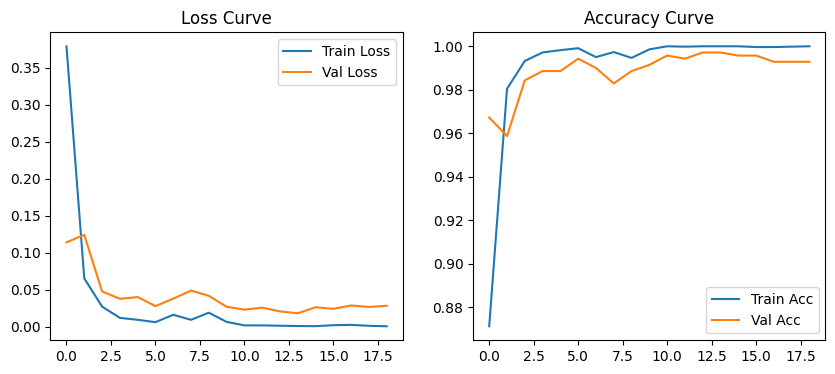


Training completed in 1166.63 seconds.

=== Train Classification Report ===
              precision    recall  f1-score   support

      glioma     1.0000    1.0000    1.0000      1296
  meningioma     1.0000    1.0000    1.0000      1316
     notumor     1.0000    1.0000    1.0000      1600
   pituitary     1.0000    1.0000    1.0000      1405

    accuracy                         1.0000      5617
   macro avg     1.0000    1.0000    1.0000      5617
weighted avg     1.0000    1.0000    1.0000      5617


=== Validation Classification Report ===
              precision    recall  f1-score   support

      glioma     1.0000    1.0000    1.0000       162
  meningioma     1.0000    0.9939    0.9969       164
     notumor     0.9901    1.0000    0.9950       200
   pituitary     1.0000    0.9943    0.9971       175

    accuracy                         0.9971       701
   macro avg     0.9975    0.9970    0.9973       701
weighted avg     0.9972    0.9971    0.9971       701


=== Test C

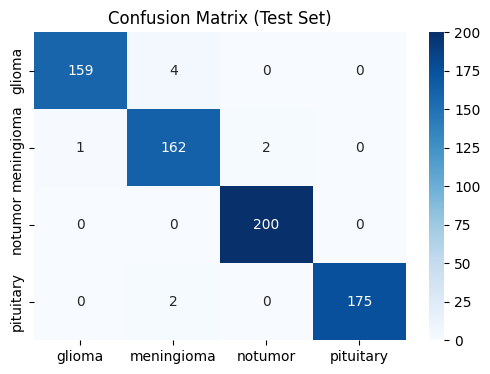


Cohen’s Kappa: 0.9829
Mean PPV: 0.9870
Mean NPV: 0.9958
Mean Sensitivity: 0.9865
Mean Specificity: 0.9958


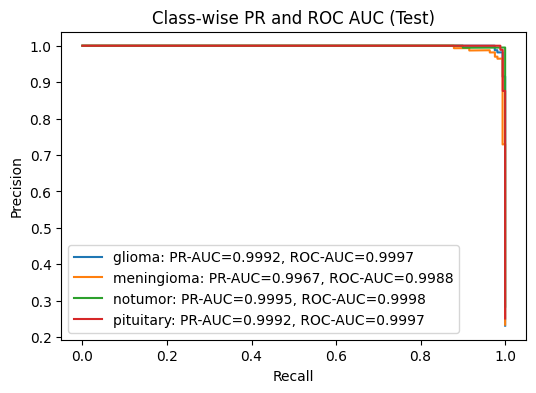


Accuracy: 0.9872
95% Confidence Interval: (0.9787, 0.9943)


Permutation test: 100%|██████████| 1000/1000 [00:00<00:00, 16453.93it/s]

Permutation-based accuracy p-value: 0.0000

GPU Memory Used: 343.48 MB
RAM Used: 2.33 GB
Inference Time: 2.65 seconds
Training Time: 1166.63 seconds


In [ ]:
# ============================================================
# 🧠 Brain MRI Tumor Classification - Xception
# ============================================================

import os, time, psutil, torch, numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score, roc_auc_score, precision_recall_curve, auc
from scipy import stats
from tqdm import tqdm

# ============================================================
# 1️⃣ Setup
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

batch_size = 32
train_dir = "/kaggle/working/brain_split/train"
val_dir   = "/kaggle/working/brain_split/val"
test_dir  = "/kaggle/working/brain_split/test"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_ds = datasets.ImageFolder(train_dir, transform=transform)
val_ds   = datasets.ImageFolder(val_dir, transform=transform)
test_ds  = datasets.ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

class_names = train_ds.classes
num_classes = len(class_names)
print("Classes:", class_names)

# ============================================================
# 2️⃣ Xception Base Model
# ============================================================

class XceptionNet(nn.Module):
    def __init__(self, num_classes=4, dropout=0.3):
        super().__init__()
        base_model = timm.create_model('xception', pretrained=True, features_only=True)
        self.features = base_model
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(2048, num_classes)
        )

    def forward(self, x):
        x = self.features(x)[-1]
        x = x.mean(dim=[2, 3])
        x = self.fc(x)
        return x

model = XceptionNet(num_classes=num_classes).to(device)

# ============================================================
# 3️⃣ Training Setup
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5, verbose=True)

epochs = 50
patience = 5
best_val_loss = float('inf')
patience_counter = 0

# ============================================================
# 4️⃣ Training Loop
# ============================================================

def evaluate_simple(model, loader, name="Set"):
    y_true, y_pred = [], []
    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.cpu().numpy())
    print(f"\n=== {name} Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

def train_model(model):
    global best_val_loss, patience_counter
    start_time = time.time()
    train_losses, val_losses, train_accs, val_accs = [], [], [], []

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, total_train = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * imgs.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()
            total_train += labels.size(0)

        avg_train_loss = train_loss / total_train
        train_accuracy = train_correct / total_train

        # Validation
        model.eval()
        val_loss, val_correct, total_val = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                total_val += labels.size(0)

        avg_val_loss = val_loss / total_val
        val_accuracy = val_correct / total_val
        scheduler.step(avg_val_loss)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | Train Acc: {train_accuracy:.4f} | Val Acc: {val_accuracy:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), "best_xception.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    end_time = time.time()
    training_time = end_time - start_time

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.legend(); plt.title("Loss Curve")
    plt.subplot(1,2,2)
    plt.plot(train_accs, label='Train Acc')
    plt.plot(val_accs, label='Val Acc')
    plt.legend(); plt.title("Accuracy Curve")
    plt.show()

    print(f"\nTraining completed in {training_time:.2f} seconds.")
    return training_time

# ============================================================
# 5️⃣ Train + Validation Reports
# ============================================================

training_time = train_model(model)
model.load_state_dict(torch.load("best_xception.pth"))

evaluate_simple(model, train_loader, "Train")
evaluate_simple(model, val_loader, "Validation")

# ============================================================
# 6️⃣ Test Evaluation (Detailed)
# ============================================================

def evaluate_test(model, loader, n_permutations=1000):
    y_true, y_pred, y_prob = [], [], []
    start_inf = time.time()

    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = F.softmax(outputs, dim=1)
            preds = probs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.numpy())
            y_prob.extend(probs.cpu().numpy())

    end_inf = time.time()
    inference_time = end_inf - start_inf

    print("\n=== Test Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix (Test Set)")
    plt.show()

    kappa = cohen_kappa_score(y_true, y_pred)
    print(f"\nCohen’s Kappa: {kappa:.4f}")

    # --- Mean PPV, NPV, Sensitivity, Specificity ---
    metrics = []
    for i in range(num_classes):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - (tp + fn + fp)
        ppv = tp / (tp + fp + 1e-8)
        npv = tn / (tn + fn + 1e-8)
        sens = tp / (tp + fn + 1e-8)
        spec = tn / (tn + fp + 1e-8)
        metrics.append((ppv, npv, sens, spec))
    metrics = np.array(metrics)
    mean_ppv, mean_npv, mean_sens, mean_spec = metrics.mean(axis=0)
    print(f"Mean PPV: {mean_ppv:.4f}")
    print(f"Mean NPV: {mean_npv:.4f}")
    print(f"Mean Sensitivity: {mean_sens:.4f}")
    print(f"Mean Specificity: {mean_spec:.4f}")

    # --- ROC & PR Curves ---
    y_true_bin = np.eye(num_classes)[y_true]
    plt.figure(figsize=(6, 4))
    for i, c in enumerate(class_names):
        roc_auc = roc_auc_score(y_true_bin[:, i], np.array(y_prob)[:, i])
        prec, rec, _ = precision_recall_curve(y_true_bin[:, i], np.array(y_prob)[:, i])
        pr_auc = auc(rec, prec)
        plt.plot(rec, prec, label=f'{c}: PR-AUC={pr_auc:.4f}, ROC-AUC={roc_auc:.4f}')
    plt.title("Class-wise PR and ROC AUC (Test)")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.show()

    # --- Accuracy and CI ---
    acc = np.mean(np.array(y_true) == np.array(y_pred))
    ci_low, ci_high = stats.binom.interval(0.95, len(y_true), acc)
    ci_low /= len(y_true)
    ci_high /= len(y_true)
    print(f"\nAccuracy: {acc:.4f}")
    print(f"95% Confidence Interval: ({ci_low:.4f}, {ci_high:.4f})")

    # --- Permutation Test ---
    perm_acc = []
    y_true_arr = np.array(y_true)
    for _ in tqdm(range(n_permutations), desc="Permutation test"):
        y_perm = np.random.permutation(y_true_arr)
        perm_acc.append(np.mean(y_perm == np.array(y_pred)))
    perm_acc = np.array(perm_acc)
    p_value = np.mean(perm_acc >= acc)
    print(f"Permutation-based accuracy p-value: {p_value:.4f}")

    # --- Resource Usage ---
    try:
        gpu_mem = torch.cuda.memory_allocated() / (1024 ** 2)
    except:
        gpu_mem = 0
    ram_usage = psutil.virtual_memory().used / (1024**3)
    print(f"\nGPU Memory Used: {gpu_mem:.2f} MB")
    print(f"RAM Used: {ram_usage:.2f} GB")
    print(f"Inference Time: {inference_time:.2f} seconds")
    print(f"Training Time: {training_time:.2f} seconds")

# ============================================================
# Run Test Evaluation
# ============================================================

evaluate_test(model, test_loader, n_permutations=1000)


Using device: cuda
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth
100%|██████████| 171M/171M [00:00<00:00, 215MB/s] 
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/50] | Train Loss: 0.2346 | Val Loss: 0.0611 | Train Acc: 0.9185 | Val Acc: 0.9829
Epoch [2/50] | Train Loss: 0.0520 | Val Loss: 0.1485 | Train Acc: 0.9815 | Val Acc: 0.9529
Epoch [3/50] | Train Loss: 0.0452 | Val Loss: 0.0570 | Train Acc: 0.9865 | Val Acc: 0.9786
Epoch [4/50] | Train Loss: 0.0195 | Val Loss: 0.0838 | Train Acc: 0.9943 | Val Acc: 0.9700
Epoch [5/50] | Train Loss: 0.0133 | Val Loss: 0.1687 | Train Acc: 0.9961 | Val Acc: 0.9444
Epoch [6/50] | Train Loss: 0.0242 | Val Loss: 0.1424 | Train Acc: 0.9915 | Val Acc: 0.9586
Epoch [7/50] | Train Loss: 0.0119 | Val Loss: 0.0277 | Train Acc: 0.9961 | Val Acc: 0.9914
Epoch [8/50] | Train Loss: 0.0049 | Val Loss: 0.0280 | Train Acc: 0.9988 | Val Acc: 0.9943
Epoch [9/50] | Train Loss: 0.0014 | Val Loss: 0.0229 | Train Acc: 0.9998 | Val Acc: 0.9957
Epoch [10/50] | Train Loss: 0.0012 | Val Loss: 0.0213 | Train Acc: 0.9996 | Val Acc: 0.9943
Epoch [11/50] | Train Loss: 0.0005 | Val Loss: 0.0234 | Train Acc: 1.0000 | Val Acc: 0.99

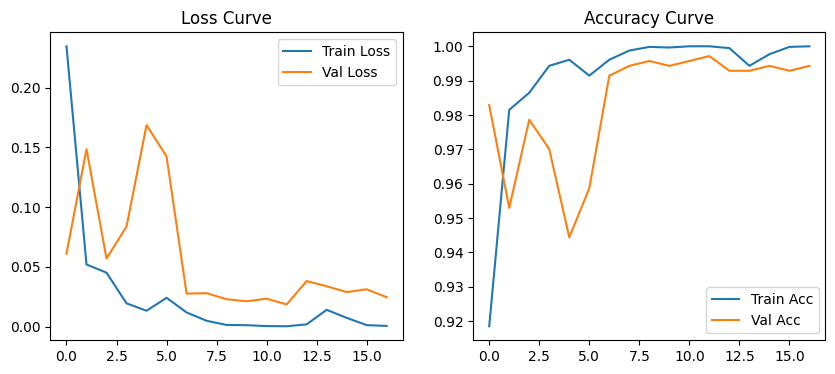


Training completed in 980.37 seconds.

=== Train Classification Report ===
              precision    recall  f1-score   support

      glioma     1.0000    1.0000    1.0000      1296
  meningioma     1.0000    1.0000    1.0000      1316
     notumor     1.0000    1.0000    1.0000      1600
   pituitary     1.0000    1.0000    1.0000      1405

    accuracy                         1.0000      5617
   macro avg     1.0000    1.0000    1.0000      5617
weighted avg     1.0000    1.0000    1.0000      5617


=== Validation Classification Report ===
              precision    recall  f1-score   support

      glioma     0.9939    1.0000    0.9969       162
  meningioma     1.0000    0.9878    0.9939       164
     notumor     0.9950    1.0000    0.9975       200
   pituitary     1.0000    1.0000    1.0000       175

    accuracy                         0.9971       701
   macro avg     0.9972    0.9970    0.9971       701
weighted avg     0.9972    0.9971    0.9971       701


=== Test Cl

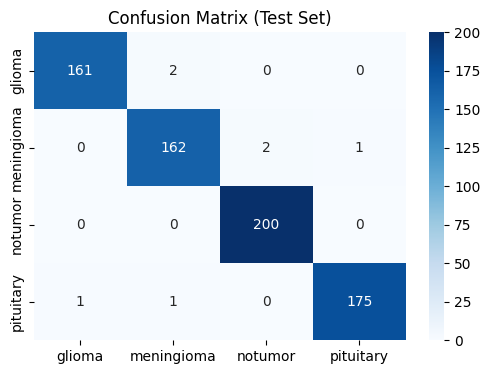


Cohen’s Kappa: 0.9867
Mean PPV: 0.9900
Mean NPV: 0.9967
Mean Sensitivity: 0.9896
Mean Specificity: 0.9967


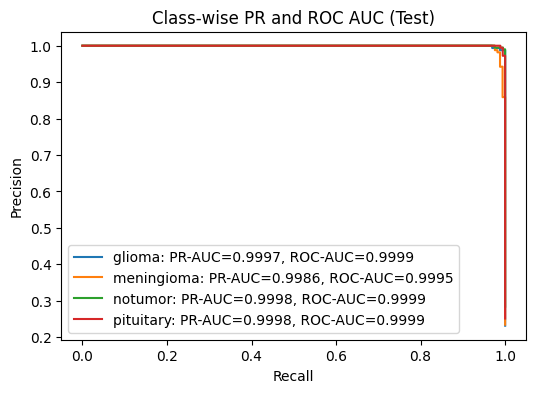


Accuracy: 0.9901
95% Confidence Interval: (0.9816, 0.9972)


Permutation test: 100%|██████████| 1000/1000 [00:00<00:00, 15893.84it/s]

Permutation-based accuracy p-value: 0.0000

GPU Memory Used: 689.88 MB
RAM Used: 2.23 GB
Inference Time: 2.71 seconds
Training Time: 980.37 seconds


In [ ]:
# ============================================================
# 🧠 Brain MRI Tumor Classification - ResNet101
# ============================================================

import os, time, psutil, torch, numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
from scipy import stats

# ============================================================
# 1️⃣ Setup
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

batch_size = 32
train_dir = "/kaggle/working/brain_split/train"
val_dir = "/kaggle/working/brain_split/val"
test_dir = "/kaggle/working/brain_split/test"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_ds = datasets.ImageFolder(train_dir, transform=transform)
val_ds = datasets.ImageFolder(val_dir, transform=transform)
test_ds = datasets.ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

class_names = train_ds.classes
num_classes = len(class_names)
print("Classes:", class_names)

# ============================================================
# 2️⃣ ResNet101 Model (Without SE)
# ============================================================

class ResNet101(nn.Module):
    def __init__(self, num_classes=4, dropout=0.3):
        super().__init__()
        base_model = models.resnet101(weights='IMAGENET1K_V1')
        self.features = nn.Sequential(*list(base_model.children())[:-2])
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(2048, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.fc(x)
        return x

model = ResNet101(num_classes=num_classes).to(device)

# ============================================================
# 3️⃣ Training Setup
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5, verbose=True)

epochs = 50
patience = 5
best_val_loss = float('inf')
patience_counter = 0

# ============================================================
# 4️⃣ Training Loop
# ============================================================

def evaluate_simple(model, loader, name="Set"):
    y_true, y_pred = [], []
    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.cpu().numpy())
    print(f"\n=== {name} Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

def train_model(model):
    global best_val_loss, patience_counter
    start_time = time.time()
    train_losses, val_losses, train_accs, val_accs = [], [], [], []

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, total_train = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * imgs.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()
            total_train += labels.size(0)

        avg_train_loss = train_loss / total_train
        train_accuracy = train_correct / total_train

        # Validation
        model.eval()
        val_loss, val_correct, total_val = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                total_val += labels.size(0)

        avg_val_loss = val_loss / total_val
        val_accuracy = val_correct / total_val
        scheduler.step(avg_val_loss)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | Train Acc: {train_accuracy:.4f} | Val Acc: {val_accuracy:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), "best_resnet101.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    end_time = time.time()
    training_time = end_time - start_time

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.legend(); plt.title("Loss Curve")
    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Acc')
    plt.plot(val_accs, label='Val Acc')
    plt.legend(); plt.title("Accuracy Curve")
    plt.show()

    print(f"\nTraining completed in {training_time:.2f} seconds.")
    return training_time

# ============================================================
# 5️⃣ Train + Validation Reports
# ============================================================

training_time = train_model(model)
model.load_state_dict(torch.load("best_resnet101.pth"))

evaluate_simple(model, train_loader, "Train")
evaluate_simple(model, val_loader, "Validation")

# ============================================================
# 6️⃣ Test Evaluation (Detailed)
# ============================================================

def evaluate_test(model, loader, n_permutations=1000):
    y_true, y_pred, y_prob = [], [], []
    start_inf = time.time()

    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = F.softmax(outputs, dim=1)
            preds = probs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.numpy())
            y_prob.extend(probs.cpu().numpy())

    end_inf = time.time()
    inference_time = end_inf - start_inf

    print("\n=== Test Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix (Test Set)")
    plt.show()

    kappa = cohen_kappa_score(y_true, y_pred)
    print(f"\nCohen’s Kappa: {kappa:.4f}")

    # --- Mean PPV, NPV, Sensitivity, Specificity ---
    metrics = []
    for i in range(num_classes):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - (tp + fn + fp)
        ppv = tp / (tp + fp + 1e-8)
        npv = tn / (tn + fn + 1e-8)
        sens = tp / (tp + fn + 1e-8)
        spec = tn / (tn + fp + 1e-8)
        metrics.append((ppv, npv, sens, spec))
    metrics = np.array(metrics)
    mean_ppv, mean_npv, mean_sens, mean_spec = metrics.mean(axis=0)
    print(f"Mean PPV: {mean_ppv:.4f}")
    print(f"Mean NPV: {mean_npv:.4f}")
    print(f"Mean Sensitivity: {mean_sens:.4f}")
    print(f"Mean Specificity: {mean_spec:.4f}")

    # --- ROC & PR Curves ---
    y_true_bin = np.eye(num_classes)[y_true]
    plt.figure(figsize=(6, 4))
    for i, c in enumerate(class_names):
        roc_auc = roc_auc_score(y_true_bin[:, i], np.array(y_prob)[:, i])
        prec, rec, _ = precision_recall_curve(y_true_bin[:, i], np.array(y_prob)[:, i])
        pr_auc = auc(rec, prec)
        plt.plot(rec, prec, label=f'{c}: PR-AUC={pr_auc:.4f}, ROC-AUC={roc_auc:.4f}')
    plt.title("Class-wise PR and ROC AUC (Test)")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.show()

    # --- Accuracy and CI ---
    acc = np.mean(np.array(y_true) == np.array(y_pred))
    ci_low, ci_high = stats.binom.interval(0.95, len(y_true), acc)
    ci_low /= len(y_true)
    ci_high /= len(y_true)
    print(f"\nAccuracy: {acc:.4f}")
    print(f"95% Confidence Interval: ({ci_low:.4f}, {ci_high:.4f})")

    # --- Permutation Test ---
    perm_acc = []
    y_true_arr = np.array(y_true)
    for _ in tqdm(range(n_permutations), desc="Permutation test"):
        y_perm = np.random.permutation(y_true_arr)
        perm_acc.append(np.mean(y_perm == np.array(y_pred)))
    perm_acc = np.array(perm_acc)
    p_value = np.mean(perm_acc >= acc)
    print(f"Permutation-based accuracy p-value: {p_value:.4f}")

    # --- Resource Usage ---
    try:
        gpu_mem = torch.cuda.memory_allocated() / (1024 ** 2)
    except:
        gpu_mem = 0
    ram_usage = psutil.virtual_memory().used / (1024**3)
    print(f"\nGPU Memory Used: {gpu_mem:.2f} MB")
    print(f"RAM Used: {ram_usage:.2f} GB")
    print(f"Inference Time: {inference_time:.2f} seconds")
    print(f"Training Time: {training_time:.2f} seconds")

# ============================================================
# Run Test Evaluation
# ============================================================

evaluate_test(model, test_loader, n_permutations=1000)